In [ ]:
#  import the packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Link with record
data = pd.read_csv("EuropeSalesRecords.csv")
data.head(5)


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Europe,Czech Republic,Beverages,Offline,C,9/12/2011,478051030,9/29/2011,4778,47.45,31.79,226716.10,151892.62,74823.48
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,10/14/2013,919133651,11/4/2013,927,109.28,35.84,101302.56,33223.68,68078.88
2,Europe,Austria,Cereal,Offline,C,8/13/2014,987410676,9/6/2014,5616,205.70,117.11,1155211.20,657689.76,497521.44
3,Europe,Bulgaria,Office Supplies,Online,L,10/31/2010,672330081,11/29/2010,6266,651.21,524.96,4080481.86,3289399.36,791082.50
4,Europe,Estonia,Fruits,Online,L,9/28/2016,579463422,11/1/2016,4958,9.33,6.92,46258.14,34309.36,11948.78


In [ ]:
data.describe()

,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,order_day_of_the_month,order_week_day,order_year,order_quarter,shipment_delay
count,1330,1.330000e+03,1330,1330.000000,1330.000000,1330.000000,1.330000e+03,1.330000e+03,1.330000e+03,1330.000000,1330.000000,1330.000000,1330.000000,1330
mean,2013-10-12 06:09:12.180451072,5.412048e+08,2013-11-06 00:46:33.383458816,4949.114286,264.893541,187.246812,1.280919e+06,9.037191e+05,3.772000e+05,15.922556,3.024812,2013.306015,2.401504,24 days 18:37:21.203007518
min,2010-01-01 00:00:00,1.006406e+08,2010-01-10 00:00:00,2.000000,9.330000,6.920000,5.038200e+02,3.736800e+02,1.301400e+02,1.000000,0.000000,2010.000000,1.000000,0 days 00:00:00
25%,2011-12-16 06:00:00,3.190004e+08,2012-01-03 00:00:00,2360.750000,81.730000,35.840000,2.661169e+05,1.577943e+05,8.482294e+04,9.000000,1.000000,2011.000000,1.000000,12 days 00:00:00
50%,2013-10-17 00:00:00,5.387164e+08,2013-11-09 00:00:00,4958.000000,154.060000,97.440000,7.613049e+05,4.332233e+05,2.735946e+05,16.000000,3.000000,2013.000000,2.000000,25 days 00:00:00
75%,2015-08-28 18:00:00,7.544628e+08,2015-10-03 18:00:00,7458.750000,437.200000,263.330000,1.742756e+06,1.108362e+06,5.476582e+05,23.000000,5.000000,2015.000000,3.000000,37 days 00:00:00
max,2017-07-23 00:00:00,9.998797e+08,2017-08-31 00:00:00,9999.000000,668.270000,524.960000,6.672676e+06,5.248025e+06,1.700449e+06,31.000000,6.000000,2017.000000,4.000000,50 days 00:00:00
std,NaN,2.573882e+08,NaN,2904.105430,217.323460,176.158873,1.443065e+06,1.134845e+06,3.689833e+05,8.689573,2.050194,2.189387,1.122851,14 days 13:52:11.833784914


In [ ]:
str(data)

'      Region                 Country        Item Type Sales Channel  \\\n0     Europe          Czech Republic        Beverages       Offline   \n1     Europe  Bosnia and Herzegovina          Clothes        Online   \n2     Europe                 Austria           Cereal       Offline   \n3     Europe                Bulgaria  Office Supplies        Online   \n4     Europe                 Estonia           Fruits        Online   \n...      ...                     ...              ...           ...   \n1325  Europe                  Norway    Personal Care       Offline   \n1326  Europe                 Ukraine           Cereal       Offline   \n1327  Europe                 Armenia             Meat       Offline   \n1328  Europe                 Denmark          Clothes       Offline   \n1329  Europe                 Finland          Clothes        Online   \n\n     Order Priority  Order Date   Order ID   Ship Date  Units Sold  \\\n0                 C   9/12/2011  478051030   9/29/2011      

In [ ]:
data['Order Date']=pd.to_datetime(data['Order Date'])
data['Ship Date']=pd.to_datetime(data['Ship Date'])
data.reset_index()

,index,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,0,Europe,Czech Republic,Beverages,Offline,C,2011-09-12,478051030,2011-09-29,4778,47.45,31.79,226716.10,151892.62,74823.48
1,1,Europe,Bosnia and Herzegovina,Clothes,Online,M,2013-10-14,919133651,2013-11-04,927,109.28,35.84,101302.56,33223.68,68078.88
2,2,Europe,Austria,Cereal,Offline,C,2014-08-13,987410676,2014-09-06,5616,205.70,117.11,1155211.20,657689.76,497521.44
3,3,Europe,Bulgaria,Office Supplies,Online,L,2010-10-31,672330081,2010-11-29,6266,651.21,524.96,4080481.86,3289399.36,791082.50
4,4,Europe,Estonia,Fruits,Online,L,2016-09-28,579463422,2016-11-01,4958,9.33,6.92,46258.14,34309.36,11948.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1325,1325,Europe,Norway,Personal Care,Offline,M,2014-01-14,634033286,2014-01-15,3394,81.73,56.67,277391.62,192337.98,85053.64
1326,1326,Europe,Ukraine,Cereal,Offline,L,2014-04-14,559183347,2014-05-21,3633,205.70,117.11,747308.10,425460.63,321847.47
1327,1327,Europe,Armenia,Meat,Offline,M,2015-11-09,781416594,2015-12-23,7390,421.89,364.69,3117767.10,2695059.10,422708.00
1328,1328,Europe,Denmark,Clothes,Offline,H,2012-05-09,713357150,2012-06-03,7088,109.28,35.84,774576.64,254033.92,520542.72


In [ ]:
data.shape

(1330, 14)

In [ ]:
data.describe()

,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,1330,1.330000e+03,1330,1330.000000,1330.000000,1330.000000,1.330000e+03,1.330000e+03,1.330000e+03
mean,2013-10-12 06:09:12.180451072,5.412048e+08,2013-11-06 00:46:33.383458816,4949.114286,264.893541,187.246812,1.280919e+06,9.037191e+05,3.772000e+05
min,2010-01-01 00:00:00,1.006406e+08,2010-01-10 00:00:00,2.000000,9.330000,6.920000,5.038200e+02,3.736800e+02,1.301400e+02
25%,2011-12-16 06:00:00,3.190004e+08,2012-01-03 00:00:00,2360.750000,81.730000,35.840000,2.661169e+05,1.577943e+05,8.482294e+04
50%,2013-10-17 00:00:00,5.387164e+08,2013-11-09 00:00:00,4958.000000,154.060000,97.440000,7.613049e+05,4.332233e+05,2.735946e+05
75%,2015-08-28 18:00:00,7.544628e+08,2015-10-03 18:00:00,7458.750000,437.200000,263.330000,1.742756e+06,1.108362e+06,5.476582e+05
max,2017-07-23 00:00:00,9.998797e+08,2017-08-31 00:00:00,9999.000000,668.270000,524.960000,6.672676e+06,5.248025e+06,1.700449e+06
std,NaN,2.573882e+08,NaN,2904.105430,217.323460,176.158873,1.443065e+06,1.134845e+06,3.689833e+05


In [ ]:
data.dtypes

,0
Region,object
Country,object
Item Type,object
Sales Channel,object
Order Priority,object
Order Date,datetime64[ns]
Order ID,int64
Ship Date,datetime64[ns]
Units Sold,int64
Unit Price,float64


In [ ]:
#time sapn of collected data
durations_=data['Order Date'].max()-data['Order Date'].min()
durations_

Timedelta('2760 days 00:00:00')

In [ ]:
data.isnull().sum()

,0
Region,0
Country,0
Item Type,0
Sales Channel,0
Order Priority,0
Order Date,0
Order ID,0
Ship Date,0
Units Sold,0
Unit Price,0


In [ ]:
#data pre processing:
data['order_day_of_the_month']=data['Order Date'].dt.day
data['order_week_day']=data['Order Date'].dt.dayofweek
data['order_month']=data['Order Date'].dt.month
data['order_year']=data['Order Date'].dt.year
data['order_quarter']=data['Order Date'].dt.quarter
data['order_year']=data['Order Date'].dt.year
data['shipment_delay']=data['Ship Date']-data['Order Date']

maping={1:'jan',2:'feb',3:'march',4:'april',5:'may',6:'june',7:'july',8:'aug',9:'sep',10:'oct',11:'nov',
        12:'dec'}
data['order_month']=data['order_month'].map(maping)

data.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,order_day_of_the_month,order_week_day,order_month,order_year,order_quarter,shipment_delay
0,Europe,Czech Republic,Beverages,Offline,C,2011-09-12,478051030,2011-09-29,4778,47.45,31.79,226716.10,151892.62,74823.48,12,0,sep,2011,3,17 days
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,2013-10-14,919133651,2013-11-04,927,109.28,35.84,101302.56,33223.68,68078.88,14,0,oct,2013,4,21 days
2,Europe,Austria,Cereal,Offline,C,2014-08-13,987410676,2014-09-06,5616,205.70,117.11,1155211.20,657689.76,497521.44,13,2,aug,2014,3,24 days
3,Europe,Bulgaria,Office Supplies,Online,L,2010-10-31,672330081,2010-11-29,6266,651.21,524.96,4080481.86,3289399.36,791082.50,31,6,oct,2010,4,29 days
4,Europe,Estonia,Fruits,Online,L,2016-09-28,579463422,2016-11-01,4958,9.33,6.92,46258.14,34309.36,11948.78,28,2,sep,2016,3,34 days


In [ ]:
print(data['order_year'].max())
print(data['order_year'].min())

2017
2010


Text(0.5, 1.0, 'Total Revenue over the year')

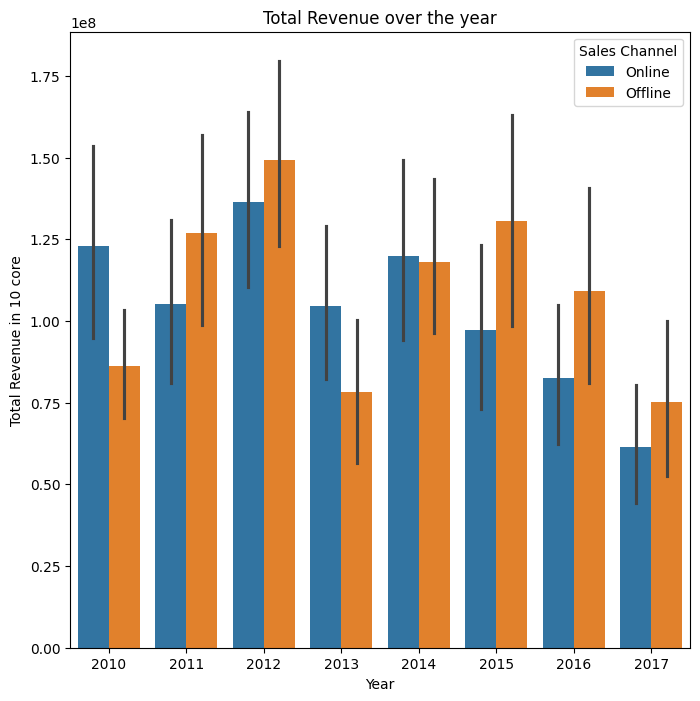

In [ ]:
#year wise revenue analysis (OVER ALL )
plt.figure(figsize=(8,8))
sns.barplot(data=data,x='order_year',y='Total Revenue',hue='Sales Channel',estimator=np.sum)
plt.ylabel('Total Revenue in 10 core')
plt.xlabel('Year')
plt.title('Total Revenue over the year')

48
['Czech Republic' 'Bosnia and Herzegovina' 'Austria' 'Bulgaria' 'Estonia'
 'Montenegro' 'Luxembourg' 'Switzerland' 'Finland' 'Belgium' 'San Marino'
 'Netherlands' 'Russia' 'Ukraine' 'Latvia' 'Serbia' 'Portugal' 'Poland'
 'Liechtenstein' 'United Kingdom' 'Slovenia' 'Malta' 'Cyprus' 'Monaco'
 'Norway' 'Armenia' 'Denmark' 'Kosovo' 'Hungary' 'Lithuania' 'Albania'
 'Moldova ' 'France' 'Spain' 'Sweden' 'Macedonia' 'Greece' 'Italy'
 'Germany' 'Andorra' 'Iceland' 'Croatia' 'Slovakia' 'Vatican City'
 'Belarus' 'Ireland' 'Romania' 'Georgia']


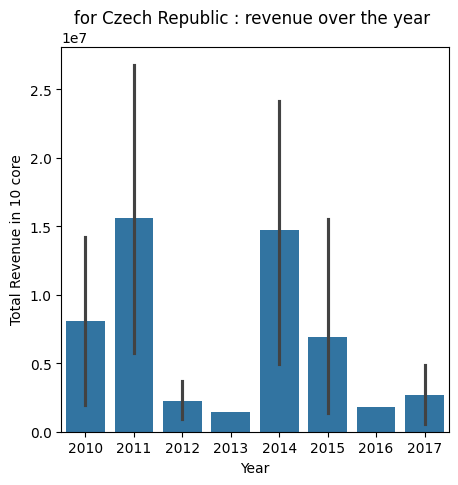

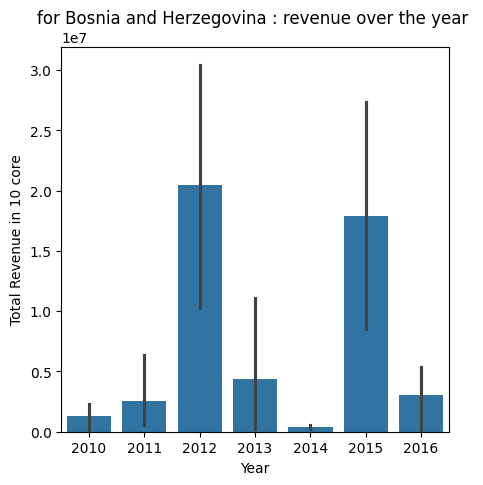

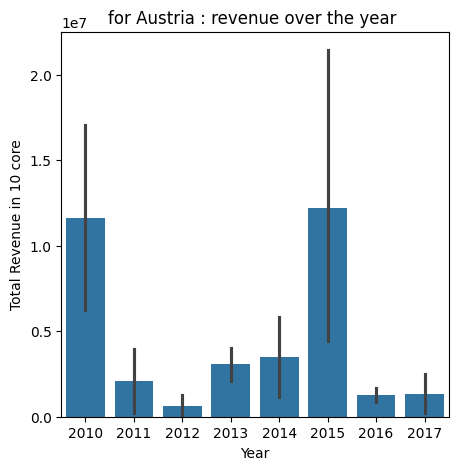

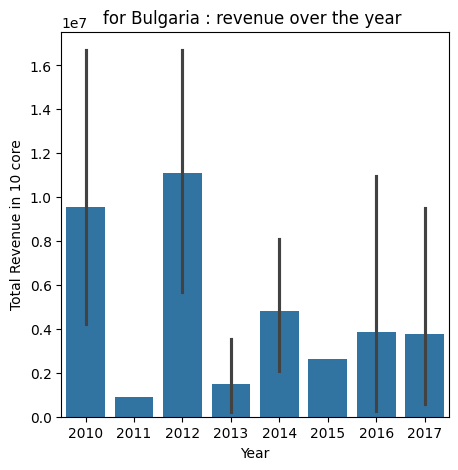

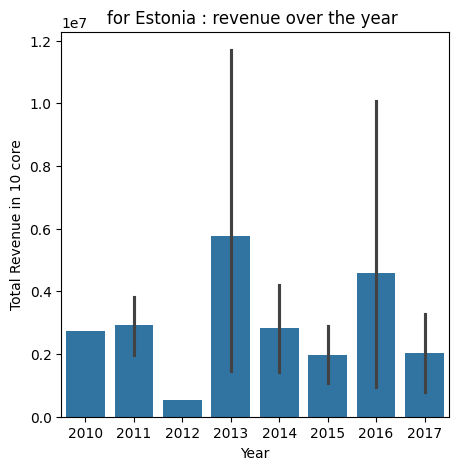

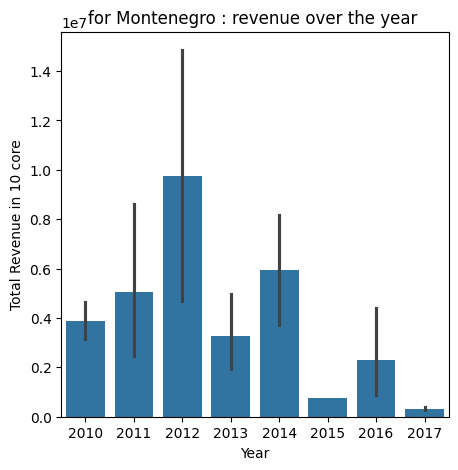

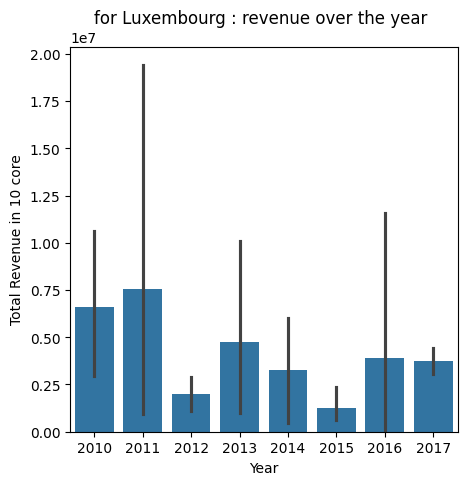

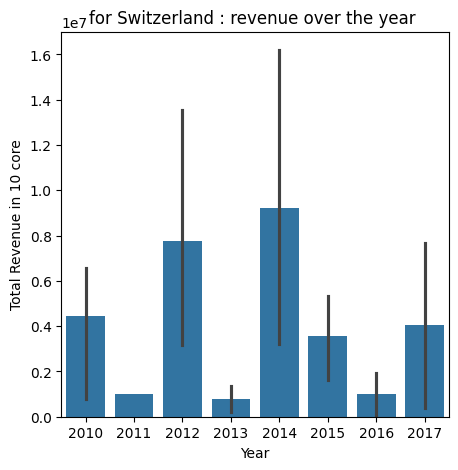

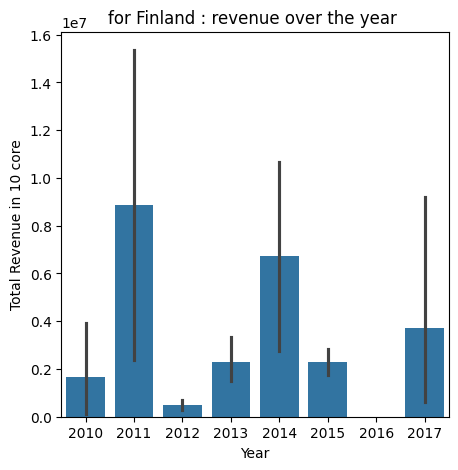

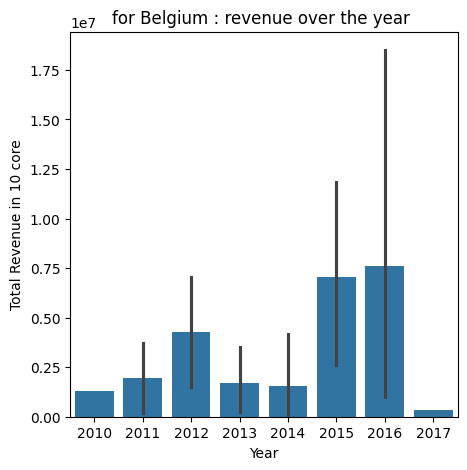

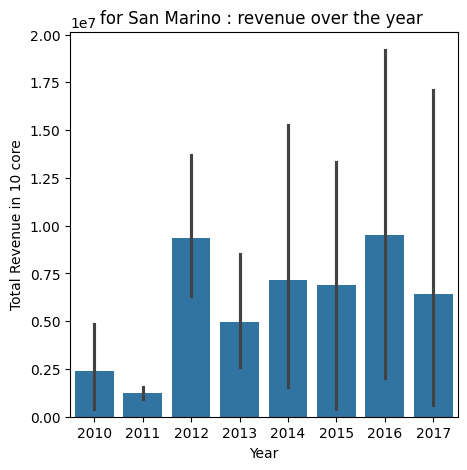

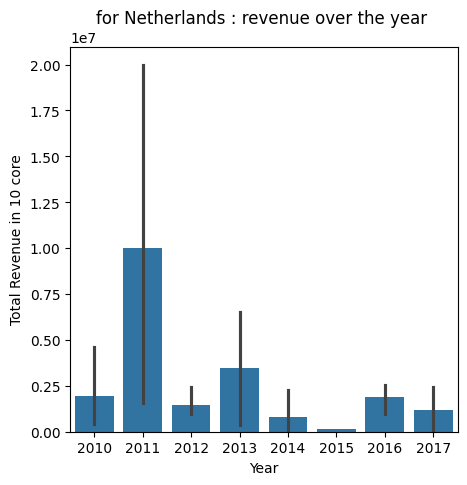

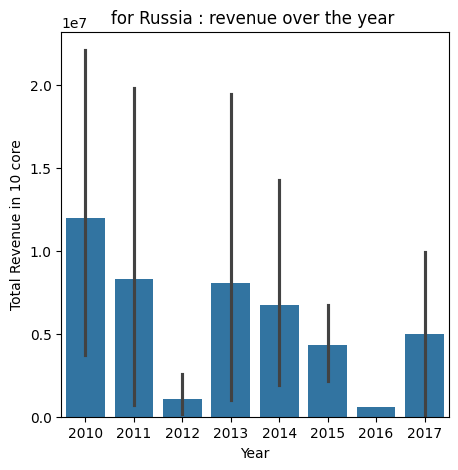

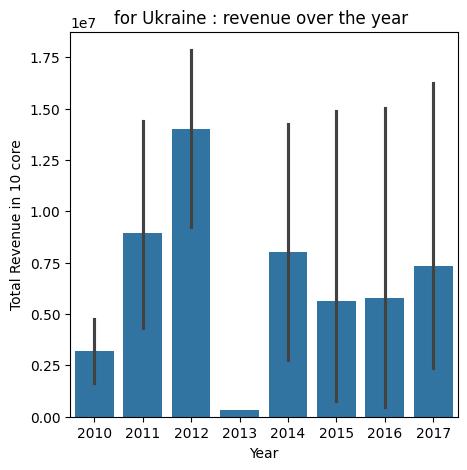

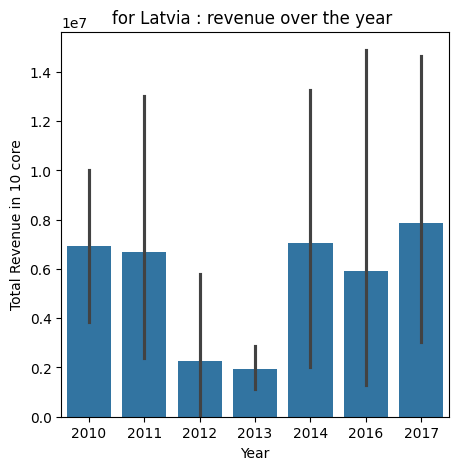

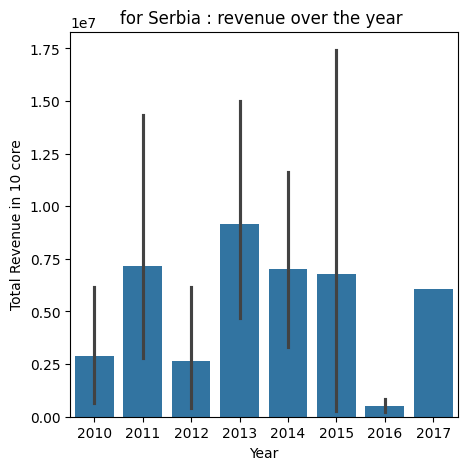

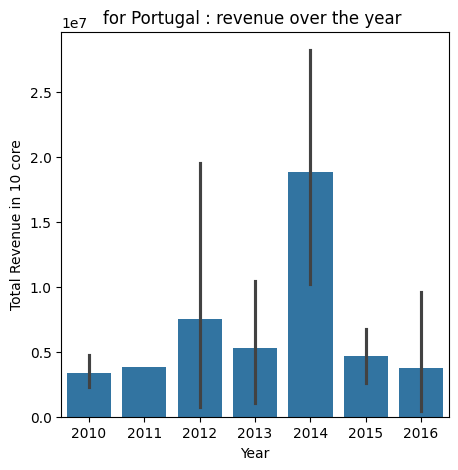

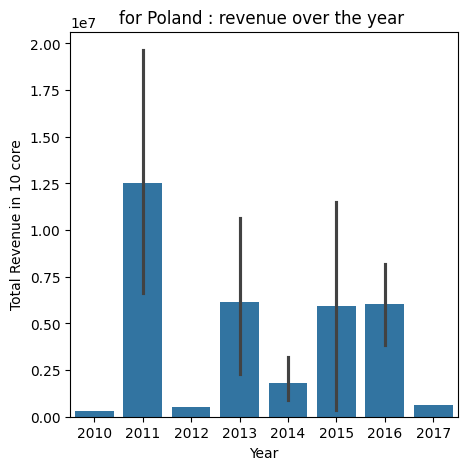

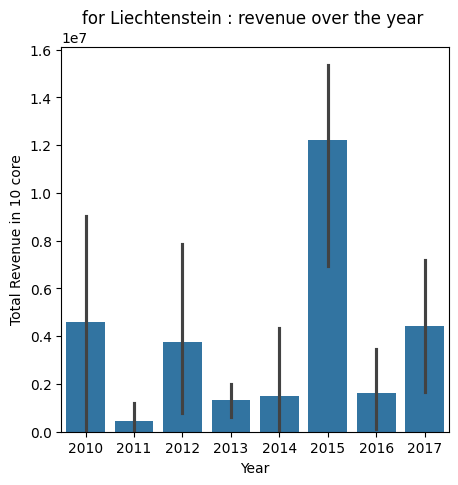

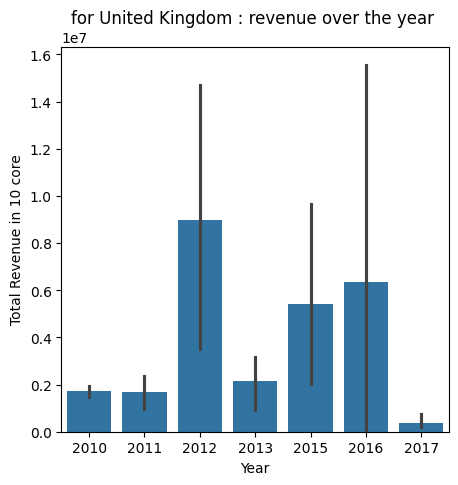

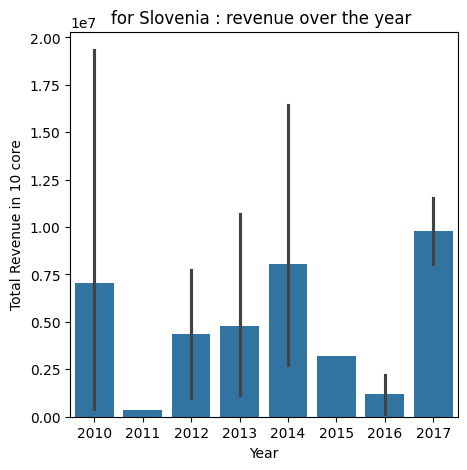

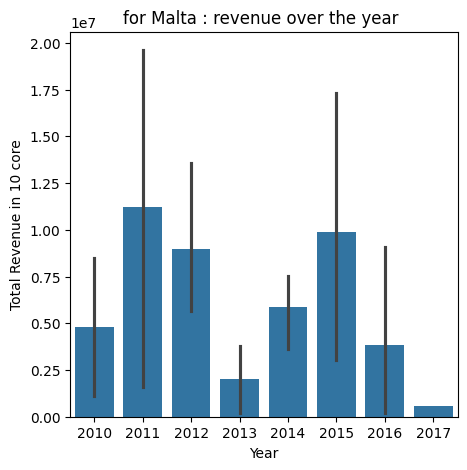

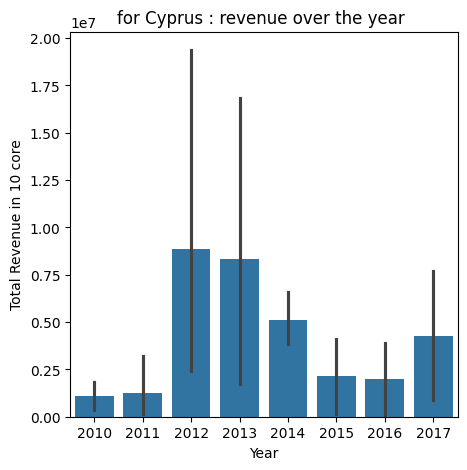

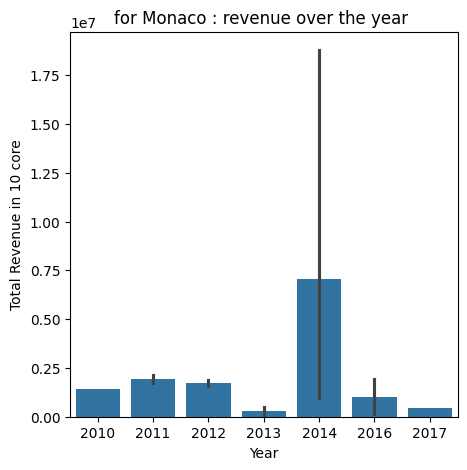

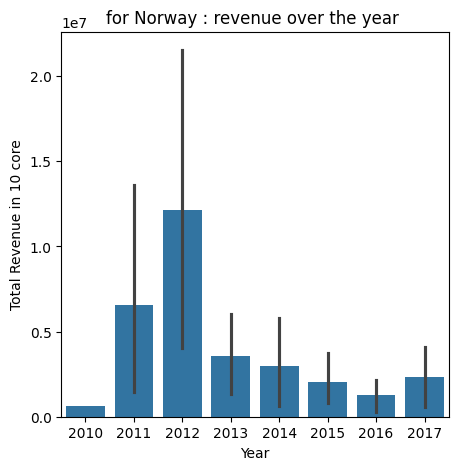

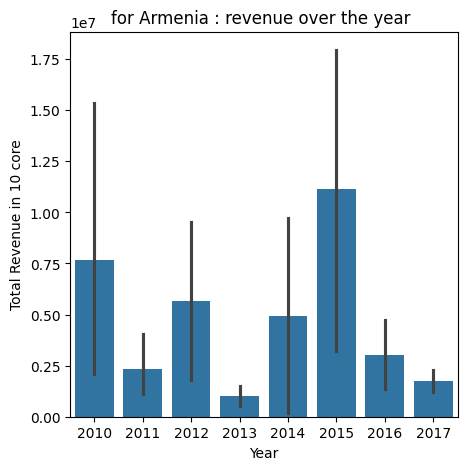

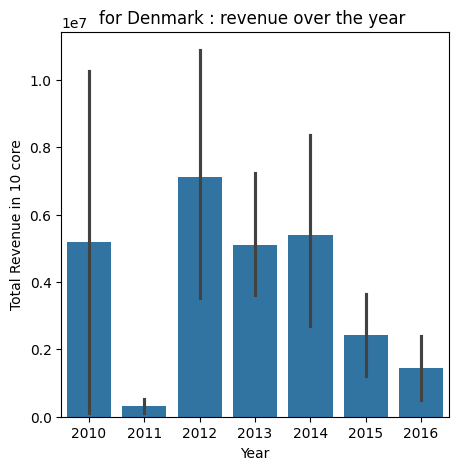

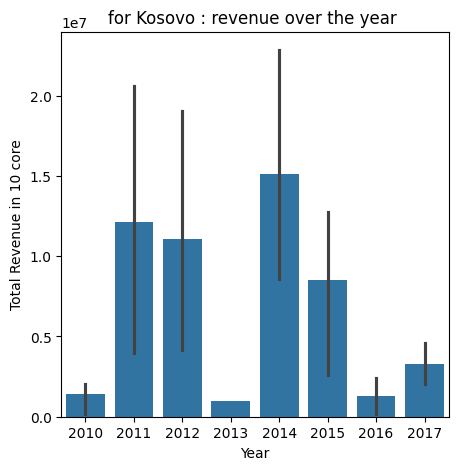

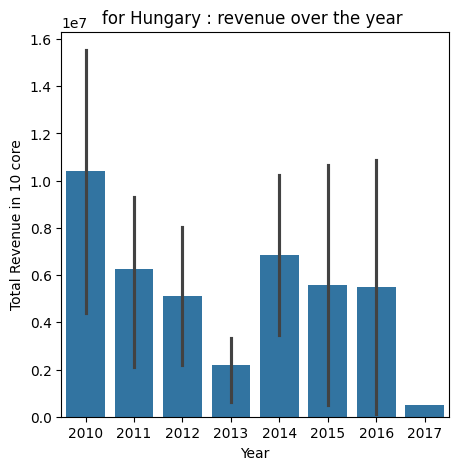

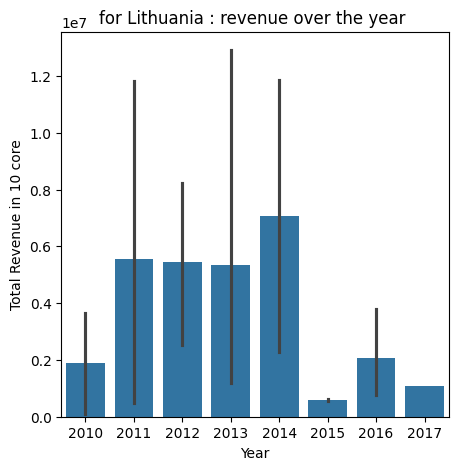

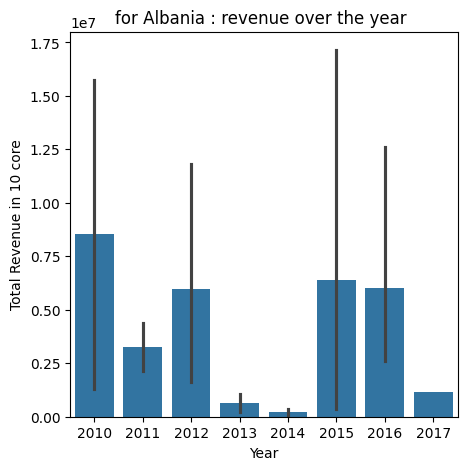

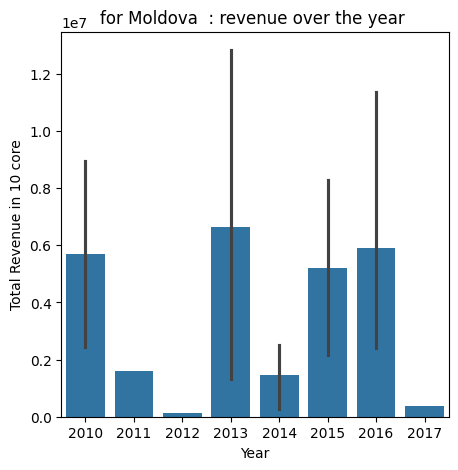

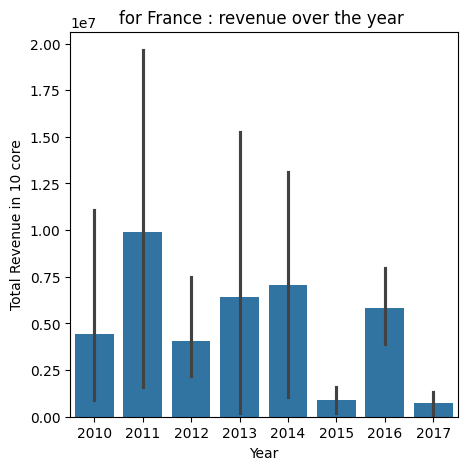

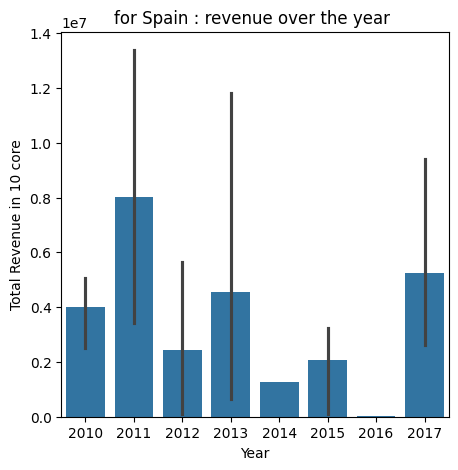

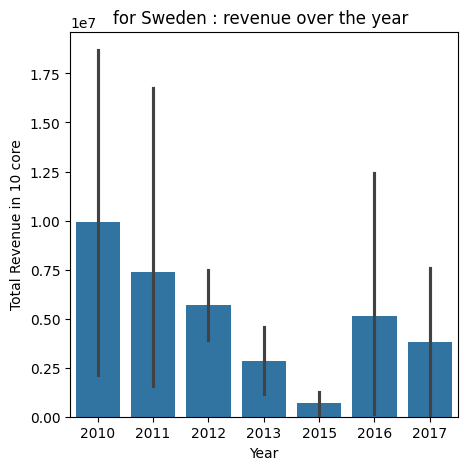

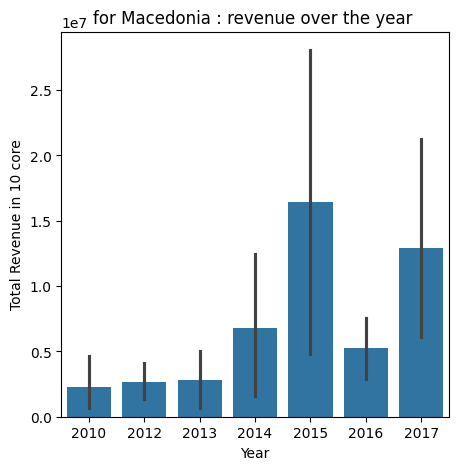

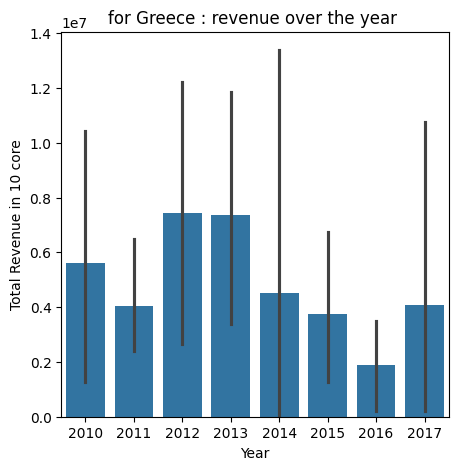

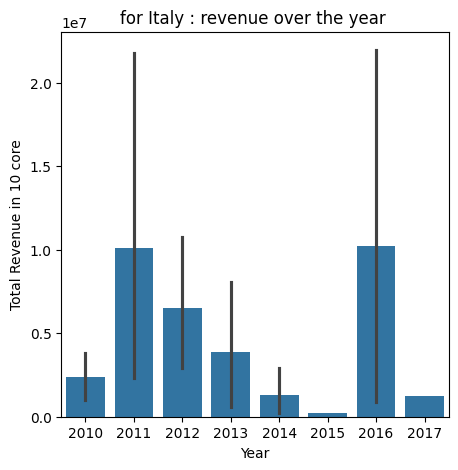

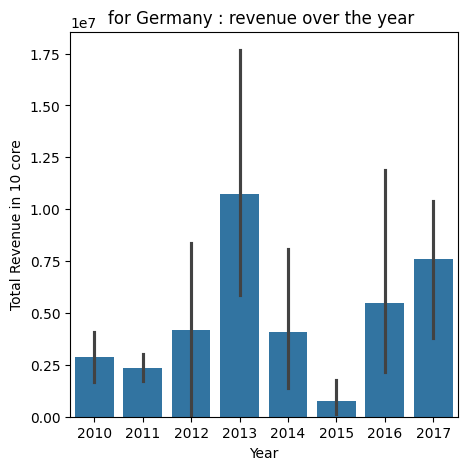

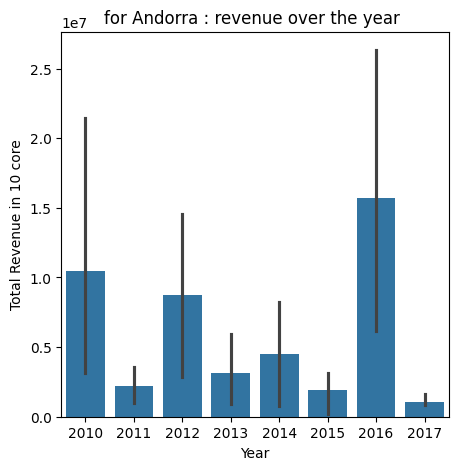

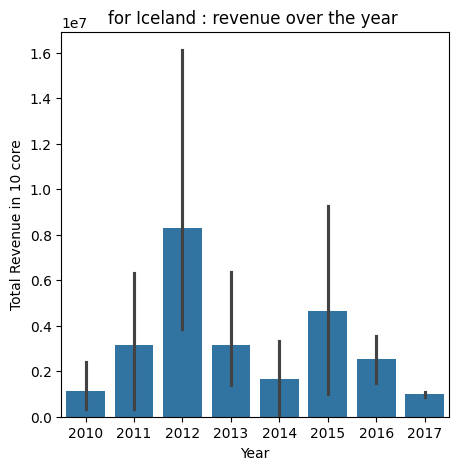

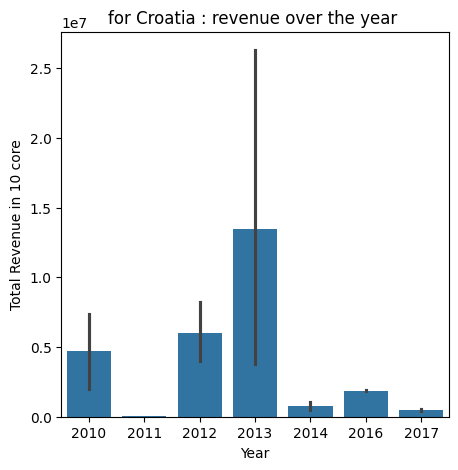

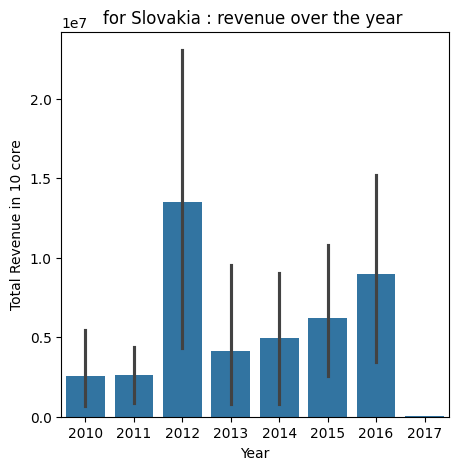

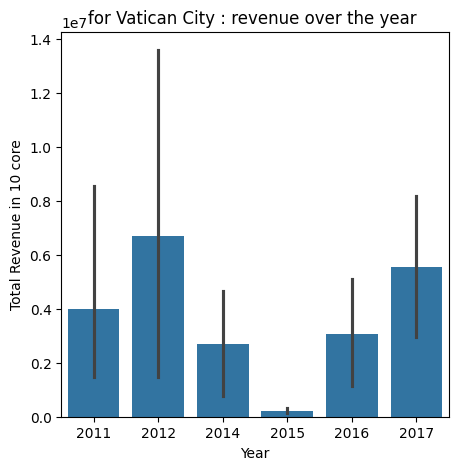

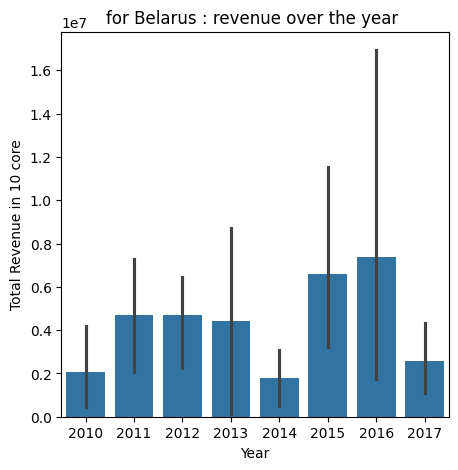

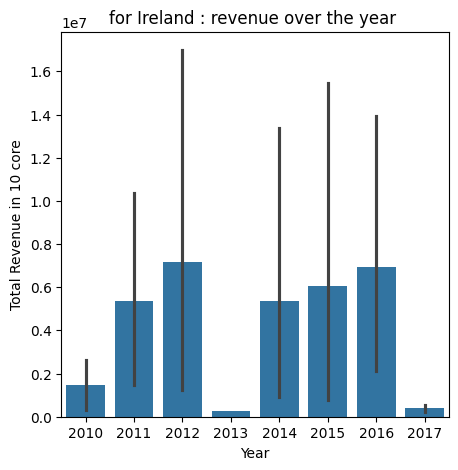

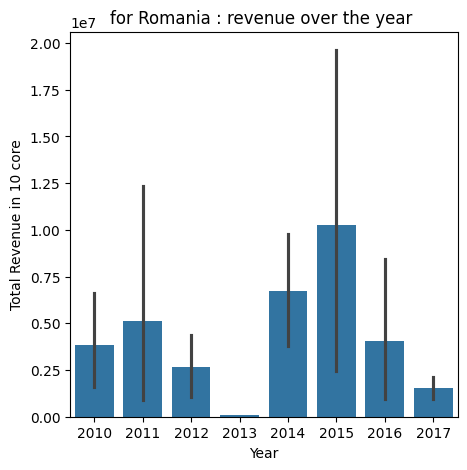

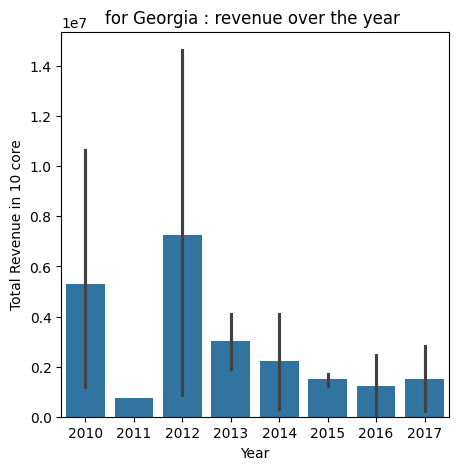

In [ ]:
#country wise total revenue:
con=data['Country'].unique()
cnt = len(con)
print(cnt)
print(con)
for i in con:
    data_con=data[data['Country']==i]
    plt.figure(figsize=(5,5))
    sns.barplot(data=data_con,x='order_year',y='Total Revenue',estimator=np.sum)
    plt.title(f'for {i} : revenue over the year ')
    plt.ylabel('Total Revenue in 10 core')
    plt.xlabel('Year')

            Total Profit  Total Revenue  Units Sold
order_year                                         
2011            21367.06       82719.78        8866
2014            22205.74       85966.62        9214
2015             8492.84       32878.92        3524
COUNTRY Armenia , PRODUCT Fruits


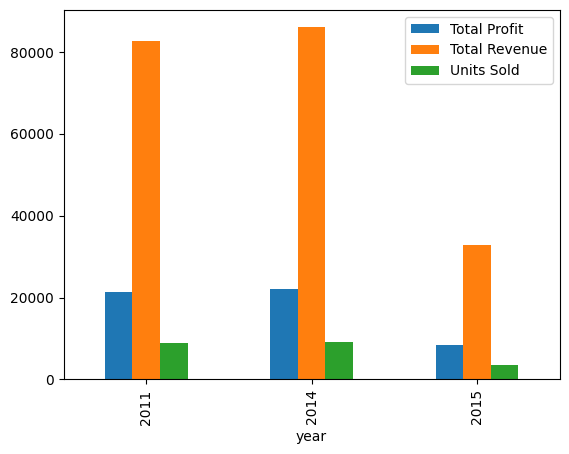

In [ ]:
#demand analysis:
#number of unit sold for each products  in each country over the year :

def demand(country,product):
    temp=data[(data['Country']==country) & (data['Item Type']==product)]
    temp_p=pd.pivot_table(data=temp,index='order_year',aggfunc={'Units Sold':'sum','Total Revenue':'sum','Total Profit':'sum'})

    print(temp_p)
    print(f'COUNTRY {country} , PRODUCT {product}')
    temp_p.plot(kind='bar',xlabel='year')


demand('Armenia','Fruits')  # function that takes country name and product name as input and gives a table and visualization about total profit ,revenue and unit solds of this product in this country

In [ ]:
#product wise total revenue all over the country :

rev_table=pd.pivot_table(data=data,index='Item Type',columns='order_year',values='Total Profit',
                         aggfunc='sum')
rev_table

order_year,2010,2011,2012,2013,2014,2015,2016,2017
Item Type,,,,,,,,
Baby Food,6891087.82,5452804.38,10612468.88,6892429.86,9764778.90,7495580.98,4626874.62,2204971.72
Beverages,1220884.92,1080540.00,1229372.64,1196079.48,946177.20,1339697.34,1321171.56,1267739.64
Cereal,7579583.22,6867496.80,5220165.75,6606776.43,5118198.66,5386892.13,3984866.79,491054.37
Clothes,5188315.68,4971520.80,8429516.64,3284089.92,7592594.40,3990729.60,8196932.16,1777615.20
Cosmetics,10188955.87,15645865.82,22534769.09,5769528.21,12261834.01,8170499.04,7318536.04,10833318.09
Fruits,181236.82,228142.65,135396.21,198571.95,179311.23,145501.34,258472.50,99296.82
Household,8320806.11,7461827.52,10834598.75,7423709.62,11429237.99,11441004.82,10550371.80,5500910.16
Meat,4894375.20,4131270.00,5445268.40,3511107.60,3326122.80,3817642.40,2882422.40,2500898.40
Office Supplies,7905396.25,11346718.75,10144061.25,7921935.00,10959383.75,14627072.50,8440065.00,6632543.75


             Total Profit  Total Revenue  Units Sold
Country                                             
Andorra        1302112.43      3274190.8       74890
Switzerland     383209.48       963588.8       22040


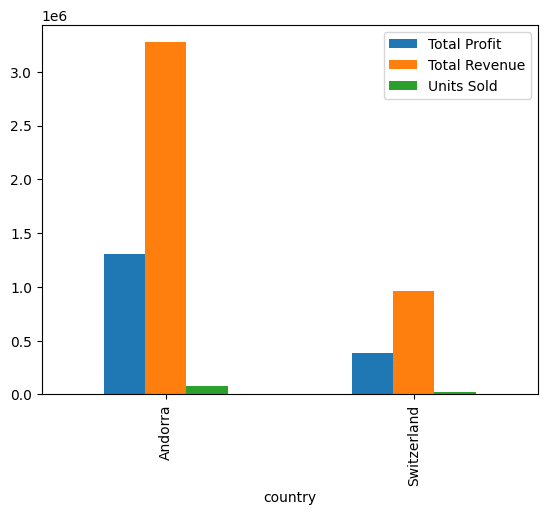

In [ ]:
#functions that  gives the month wise analysis of certain product :
def prod_analysis(product,year,month):
    te=data[(data['Item Type']==product) & (data['order_year']==year) & (data['order_month']==month)]
    size=te.shape[0]
    if size==0:
        print('this product was not sold at this time in this location')
    else:
        prod=pd.pivot_table(data=te,index='Country',aggfunc={'Total Revenue':'sum','Units Sold':'sum',
                                                             'Total Profit':'sum'})
        print(prod)
        prod.plot(kind='bar',xlabel='country')
prod_analysis('Cosmetics',2016,'feb')

                          Total Revenue  Units Sold
order_year order_quarter                           
2010       1                   65981.76        7072
           2                  169395.48       18156
           3                  264505.50       28350
           4                  201751.92       21624
2011       1                  223621.44       23968
           2                  188885.85       20245
           3                  151911.06       16282
           4                  318806.10       34170
2012       1                  226597.71       24287
           2                  152806.74       16378
           3                   44793.33        4801
           4                   99970.95       10715
2013       1                  268125.54       28738
           2                   62492.34        6698
           3                  196863.00       21100
           4                  241264.47       25859
2014       1                  115775.97       12409
           2

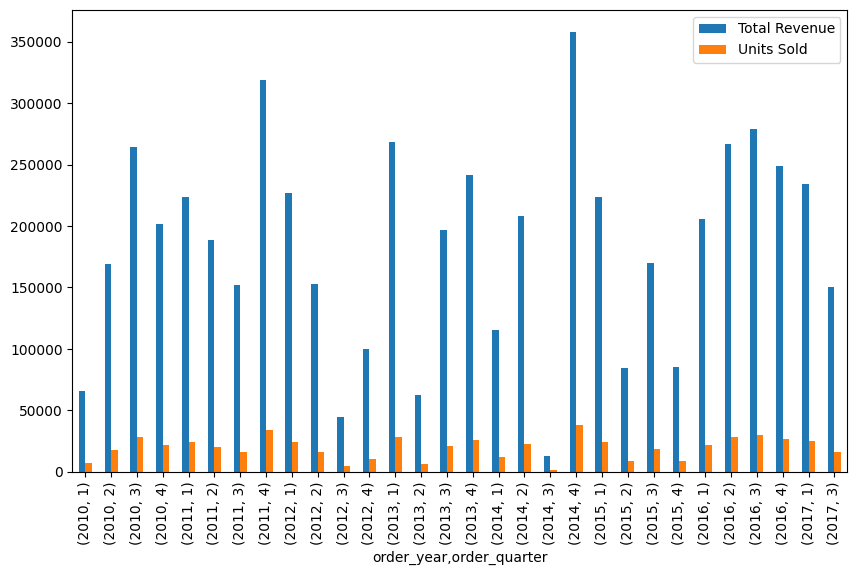

In [ ]:
#total revenue and sells  across the whole time for a specific product:

def product_rev_sell(product):
    df=data[data['Item Type']==product]
    df=pd.pivot_table(data=df,index=['order_year','order_quarter'],aggfunc={'Units Sold':'sum',
                                                                            'Total Revenue':'sum'})
    print(df)

    df.plot(kind='bar',figsize=(10,6))

product_rev_sell('Fruits')

year wise sales for all product for Finland
Item Type   Baby Food  Beverages     Cereal   Clothes   Fruits      Meat  \
order_year                                                                 
2010        490611.48        NaN  129164.22       NaN  9832.80       NaN   
2011              NaN  122602.14  355777.44       NaN      NaN       NaN   
2012              NaN  118718.46        NaN       NaN      NaN       NaN   
2013              NaN        NaN  477145.74       NaN      NaN       NaN   
2014        831873.08        NaN        NaN  691070.4      NaN  423108.4   
2015              NaN        NaN        NaN       NaN      NaN       NaN   
2016              NaN        NaN        NaN       NaN   130.14       NaN   
2017         32879.98        NaN        NaN       NaN      NaN       NaN   

Item Type   Office Supplies  Personal Care     Snacks  Vegetables  
order_year                                                         
2010                    NaN            NaN        NaN      

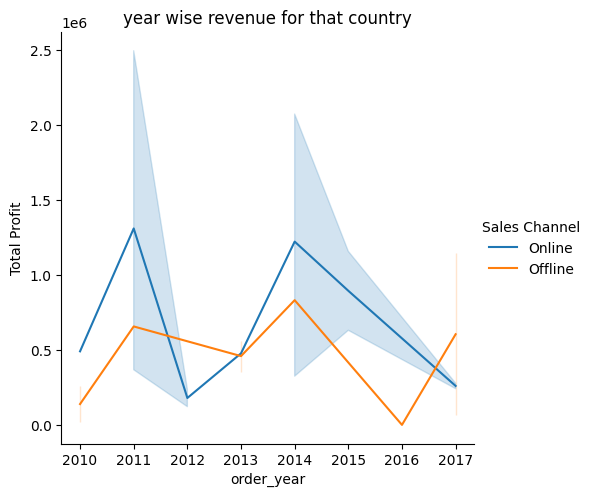

In [ ]:
#year wise sales in a country  for all product:
def product(country):
    dat=data[data['Country']==country]
    print(f'year wise sales for all product for {country}')
    t=pd.pivot_table(data=dat,index='order_year',columns='Item Type',values='Total Profit',aggfunc='sum')
    print(t)
    sns.relplot(kind='line',data=dat,x='order_year',y='Total Profit',hue='Sales Channel',estimator=np.sum)
    plt.title('year wise revenue for that country')
product('Finland')

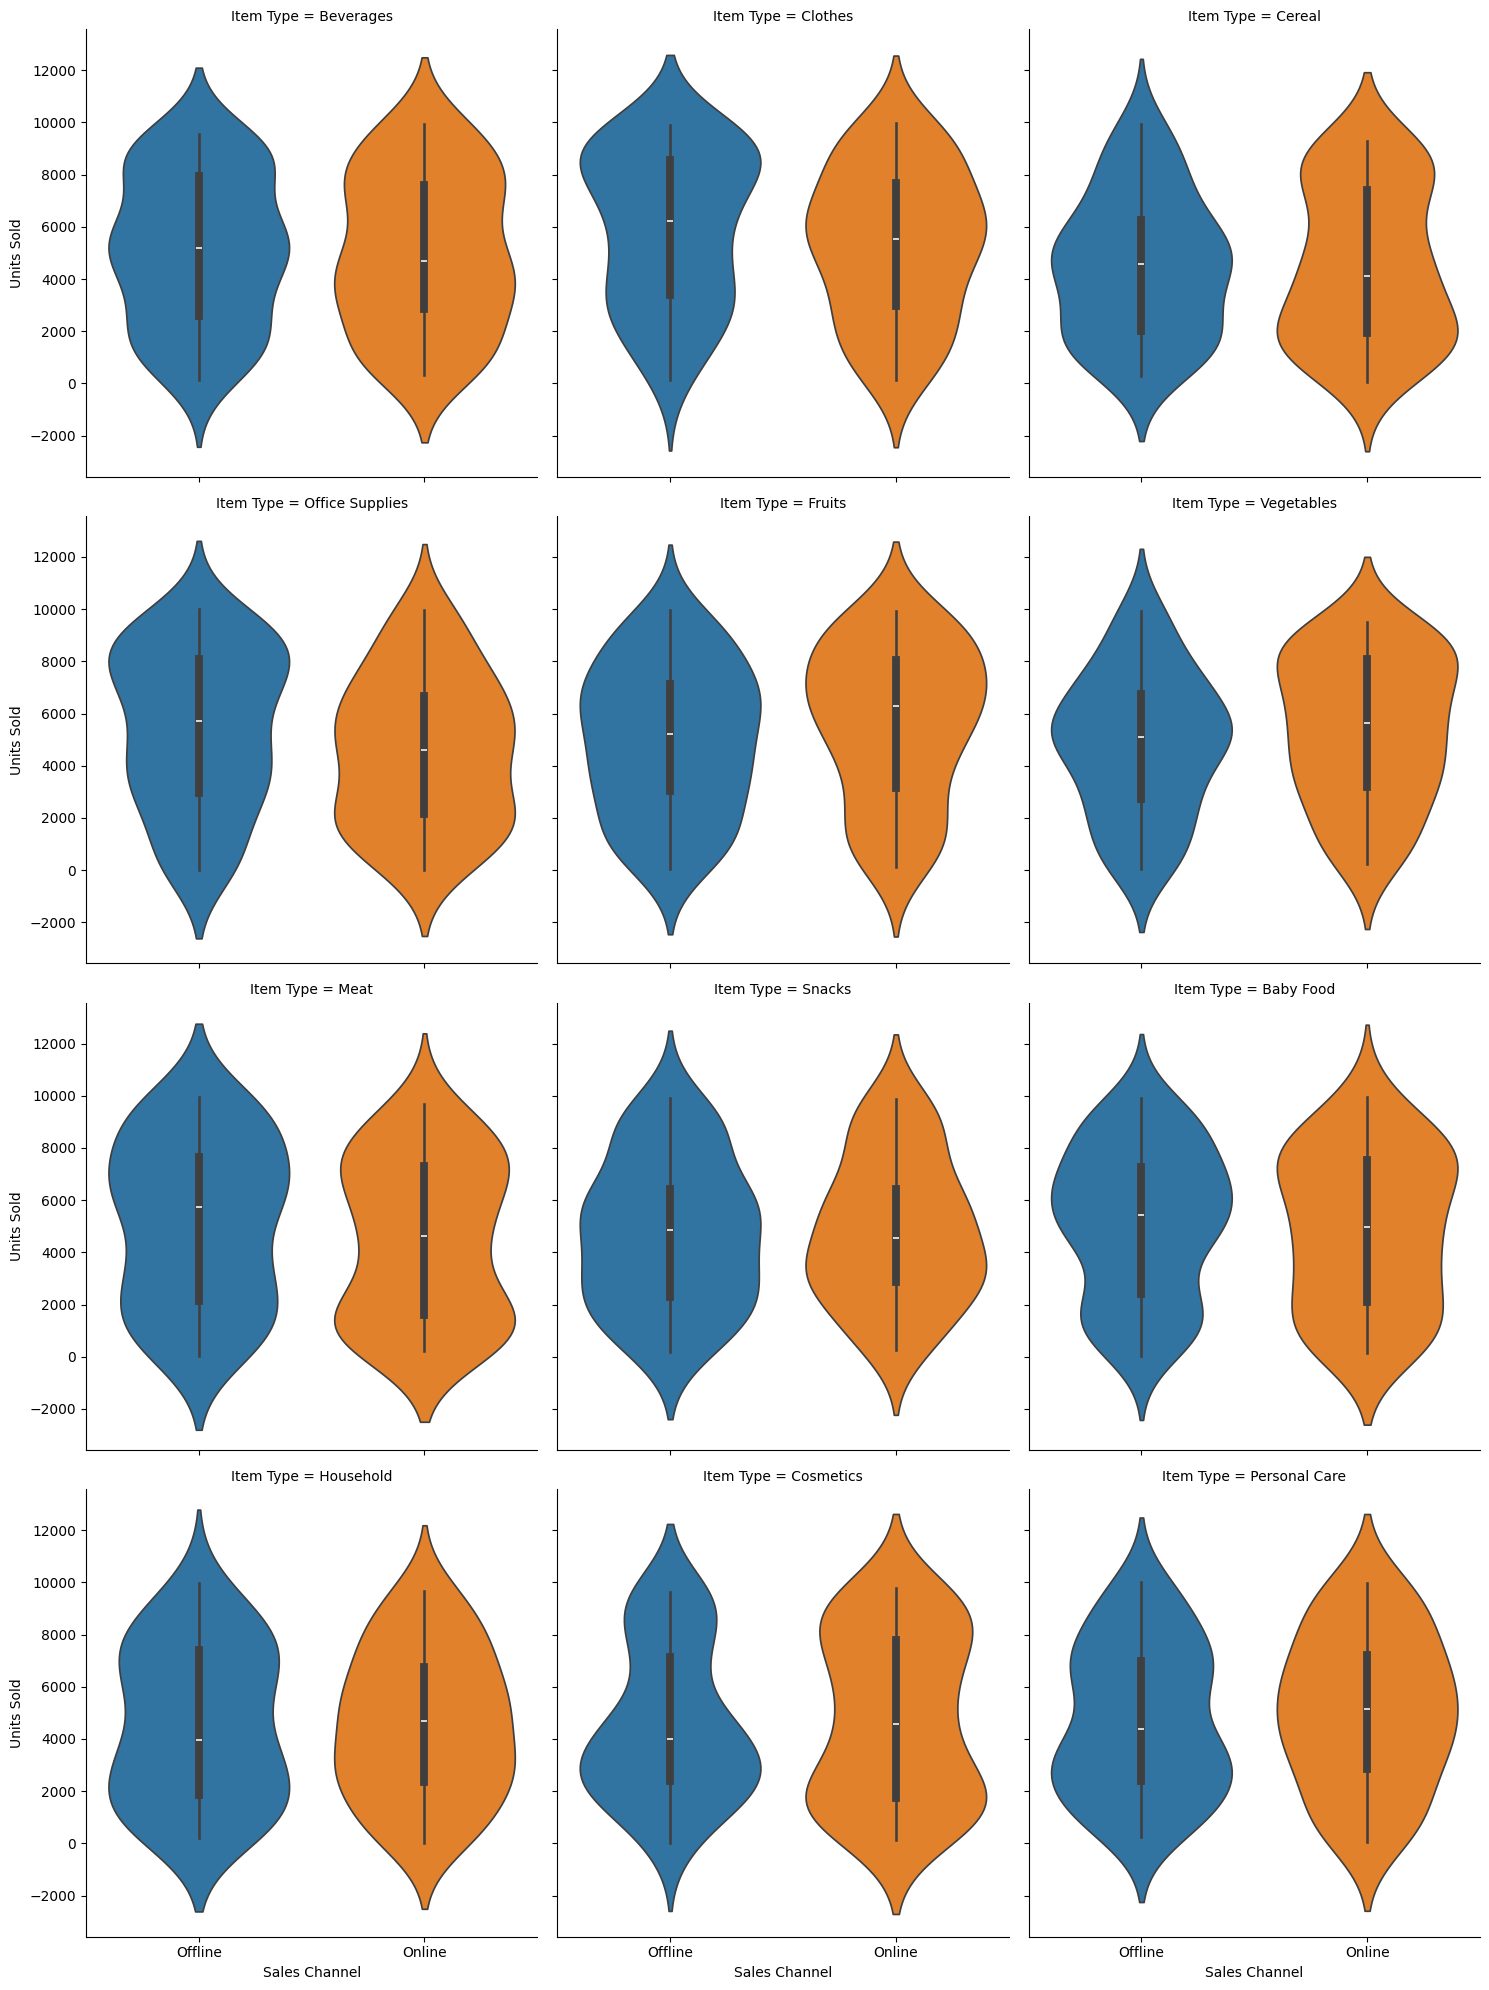

In [ ]:
sns.catplot(
    kind='violin',
    data=data, hue= 'Sales Channel',
    x='Sales Channel',
    y='Units Sold',col='Item Type', col_wrap=3
)

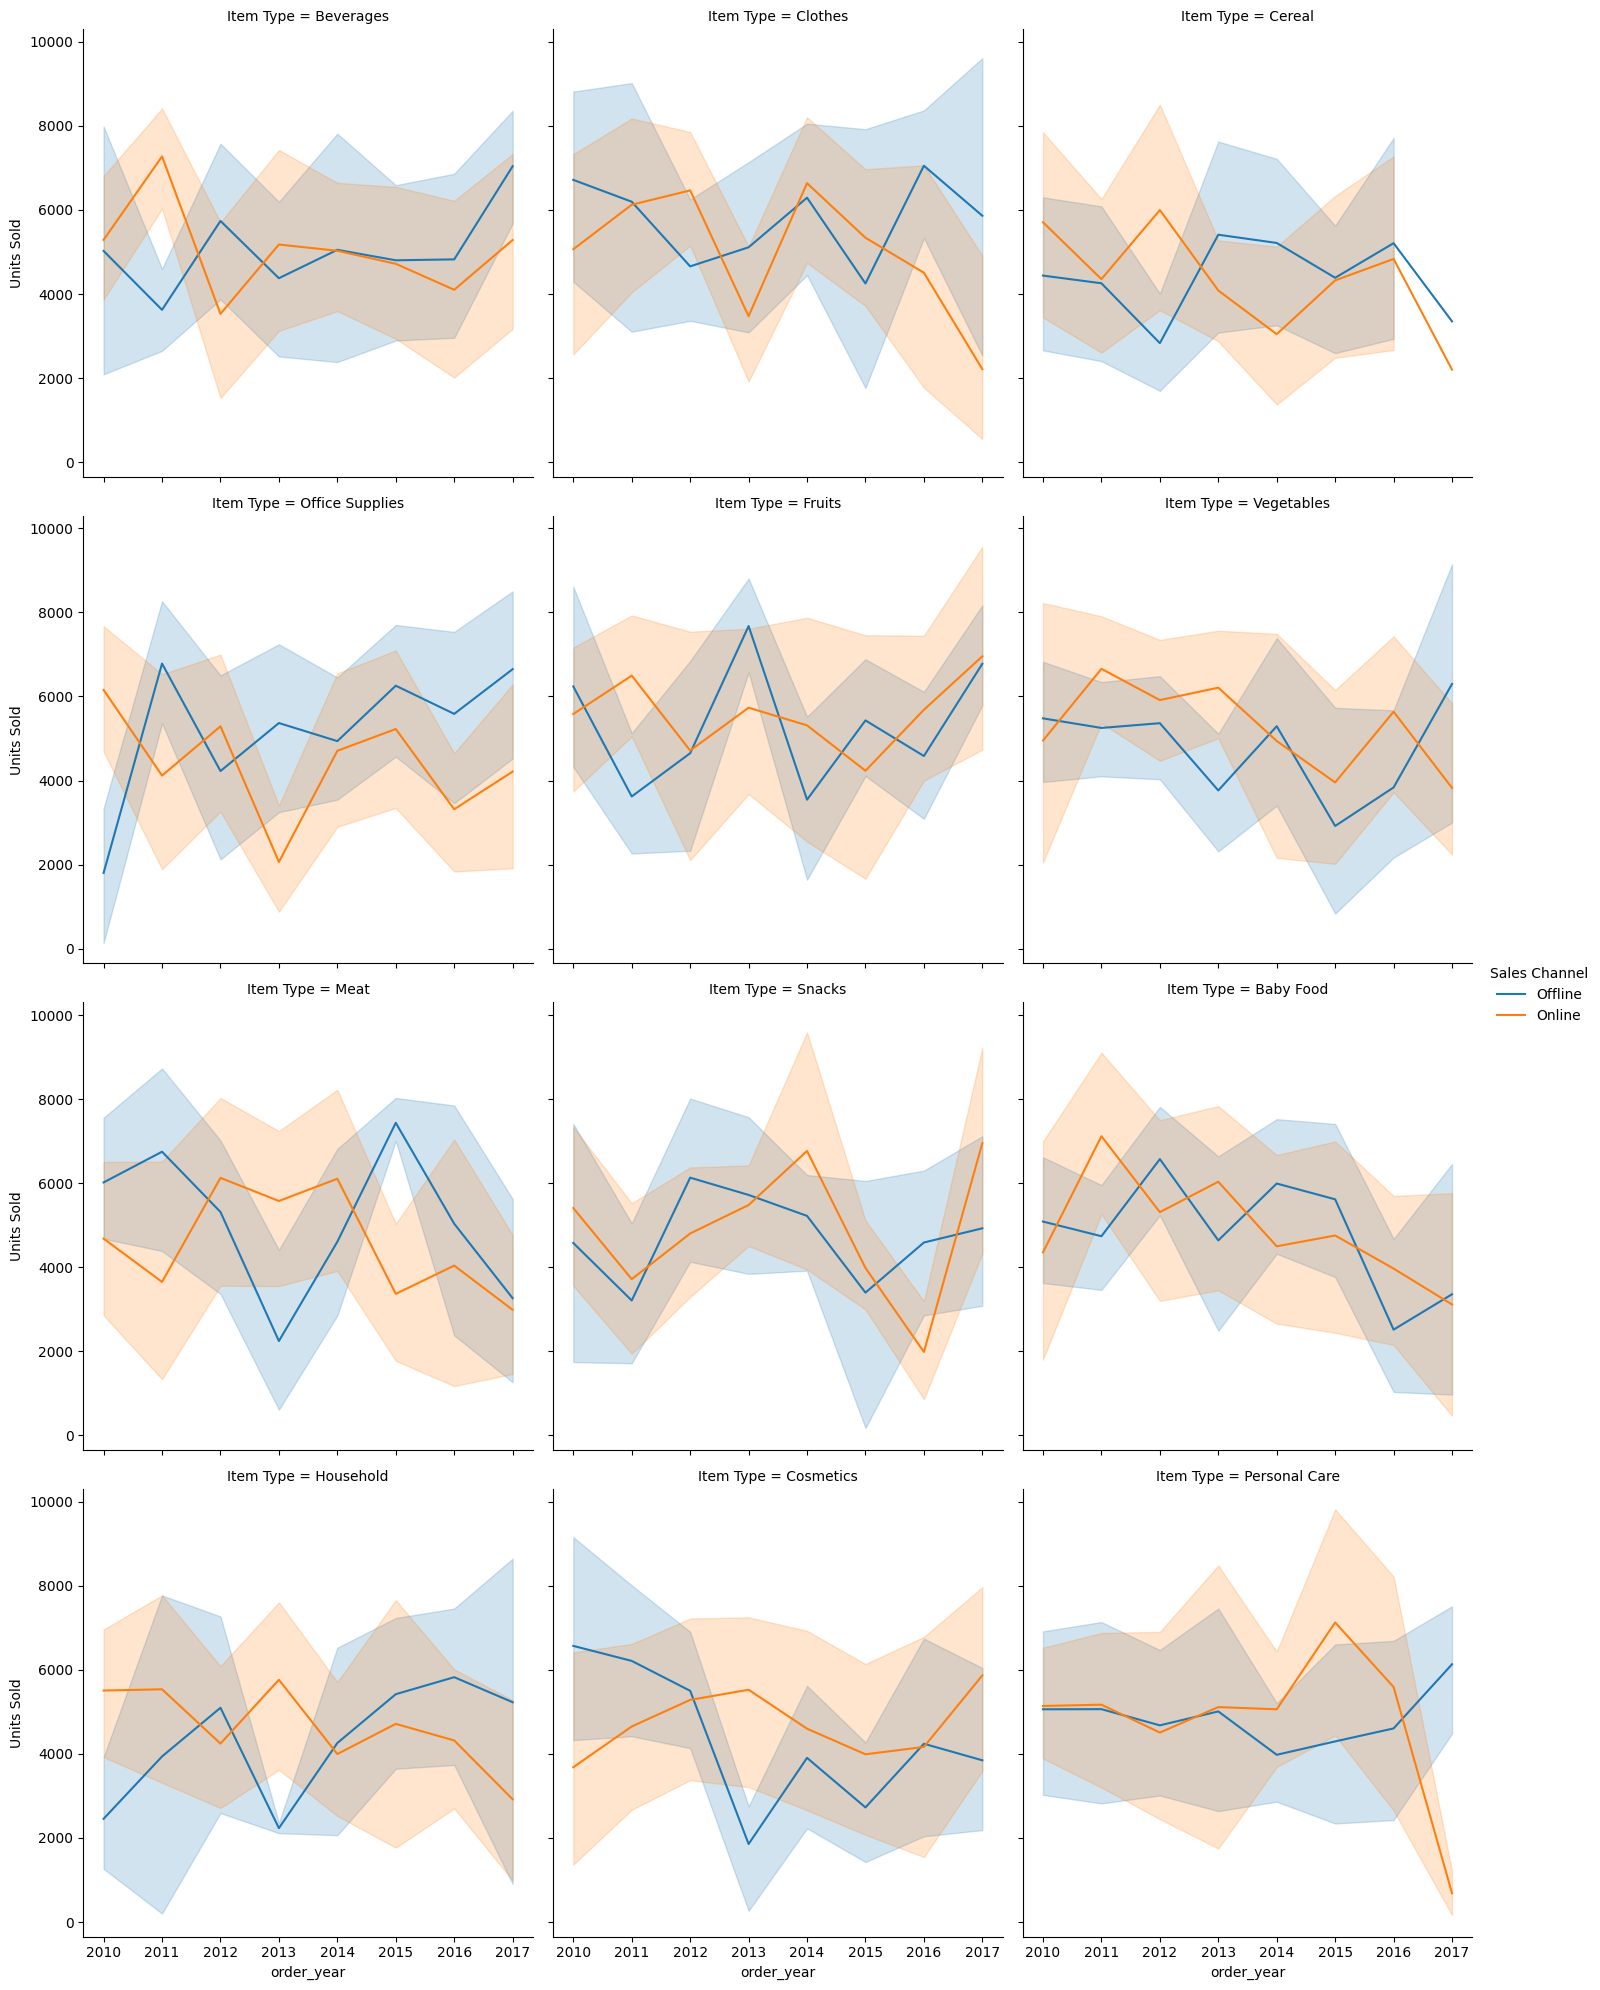

In [ ]:
#unit sold year wise
sns.relplot(kind='line',data=data,x='order_year',y='Units Sold',col='Item Type',col_wrap=3,hue='Sales Channel')

Sales Channel    Offline  Online
Item Type                       
Baby Food         334927  227779
Beverages         291836  321297
Cereal            211326  254359
Clothes           298383  293002
Cosmetics         256198  277093
Fruits            288877  302795
Household         190554  249695
Meat              282173  251203
Office Supplies   358036  259605
Personal Care     296688  263792
Snacks            231597  258563
Vegetables        285566  296978
products that were sold more in online than offline
Sales Channel  Offline  Online
Item Type                     
Beverages       291836  321297
Cereal          211326  254359
Cosmetics       256198  277093
Fruits          288877  302795
Household       190554  249695
Snacks          231597  258563
Vegetables      285566  296978


<Axes: title={'center': 'products that sold more in online'}, xlabel='Item Type'>

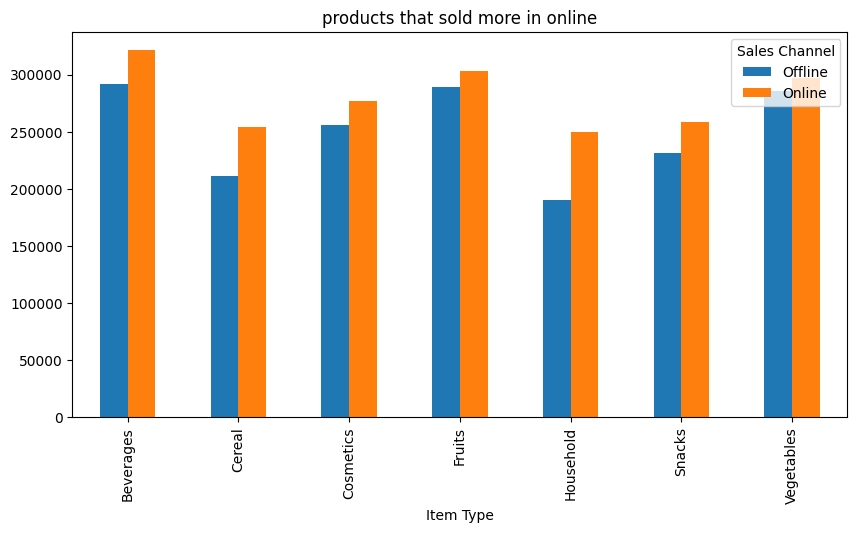

In [ ]:
#product vs sales chaneels:
sales_chnl=pd.pivot_table(data=data,index='Item Type',columns='Sales Channel',values='Units Sold',aggfunc='sum')
#sales_chnl['more_sold_way']='online' if sales_chnl['Online']>sales_chnl['Offline'] else 'offline'
print(sales_chnl)
sales_on=sales_chnl[sales_chnl['Online']>sales_chnl['Offline']]
print('products that were sold more in online than offline')
print(sales_on)
sales_on.plot(kind='bar',figsize=(10,5),title='products that sold more in online')

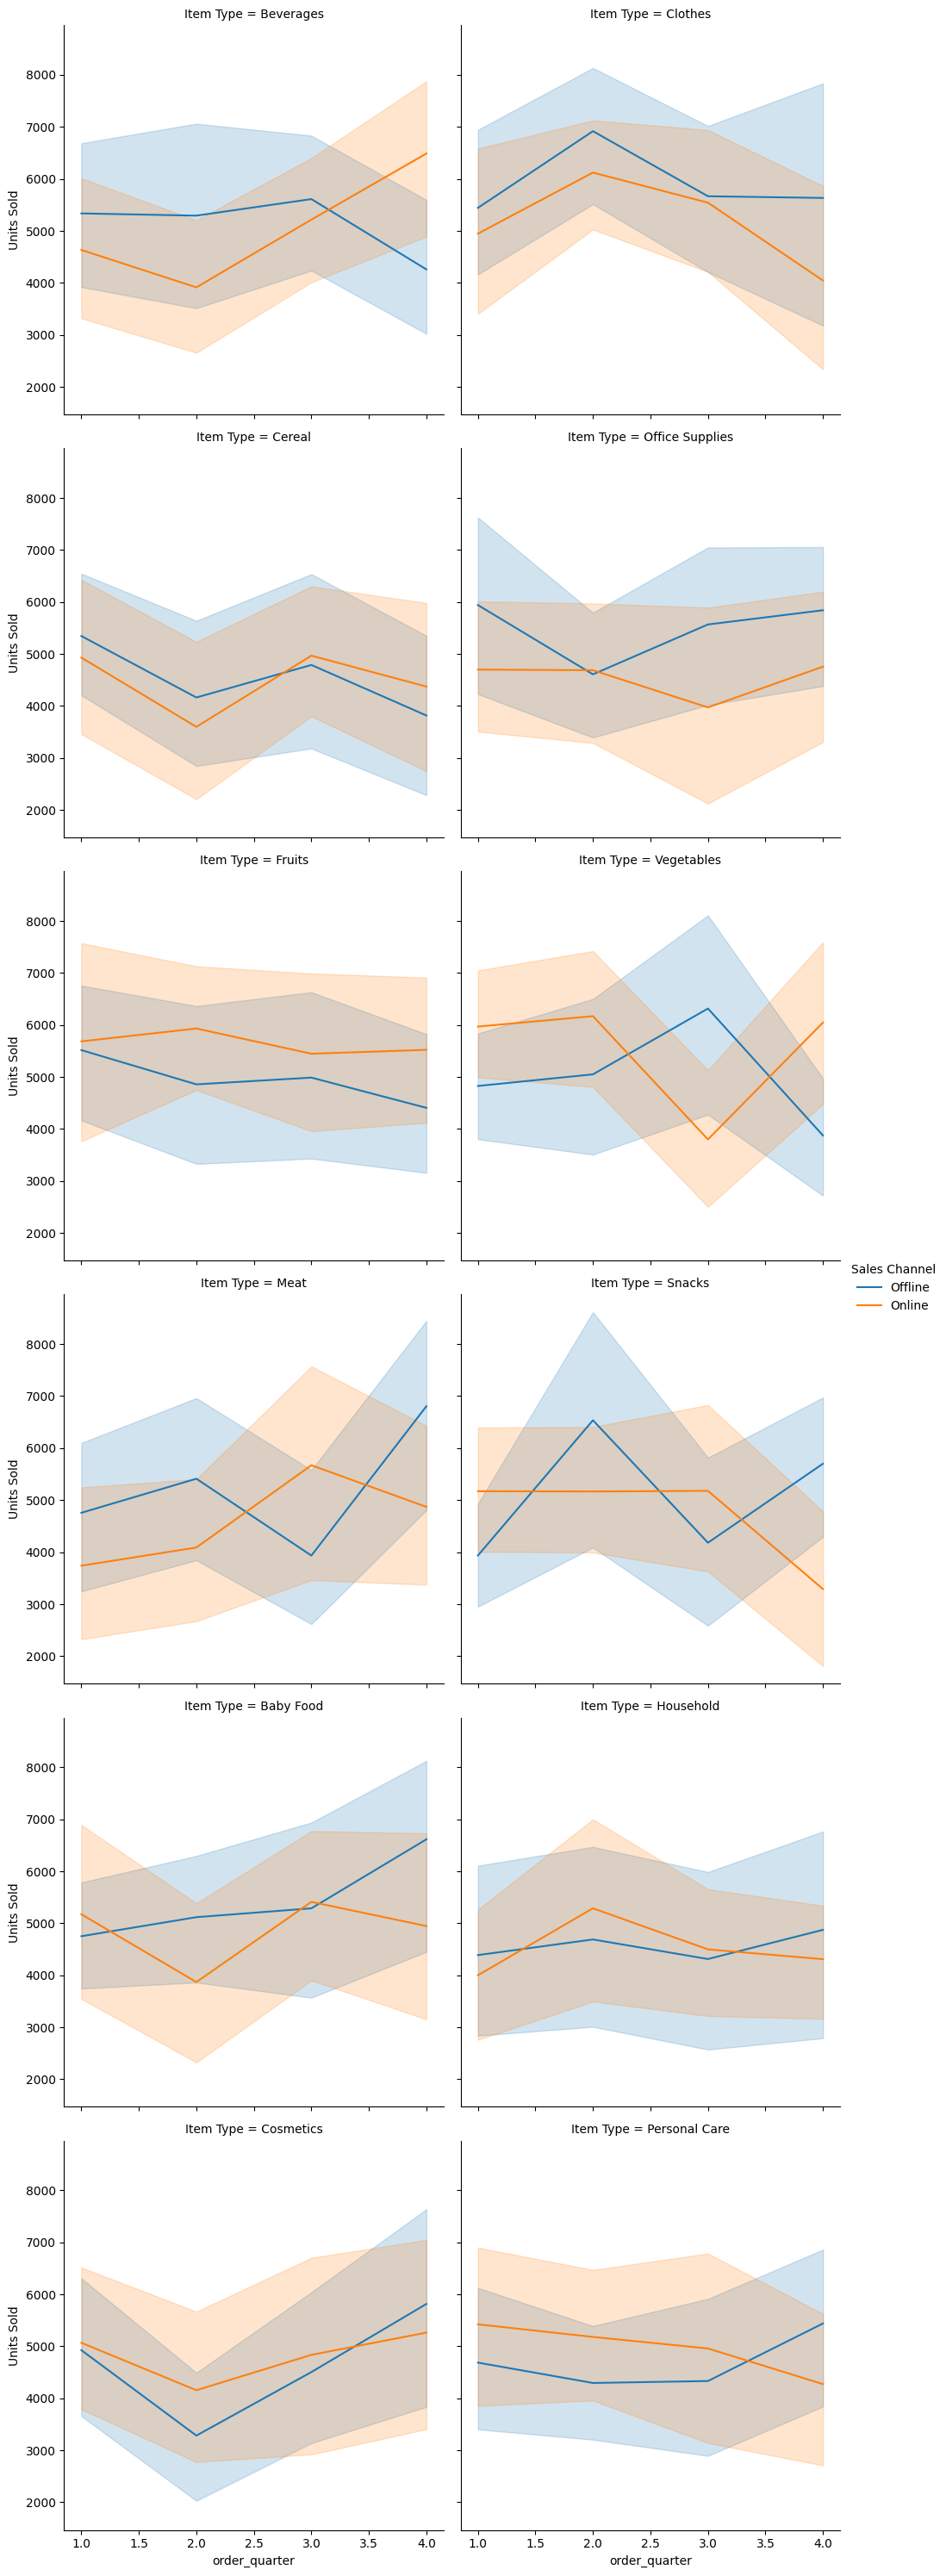

In [ ]:
#quarter wise product sell:
sns.relplot(kind='line',data=data,x='order_quarter',y='Units Sold',col='Item Type',col_wrap=2,hue='Sales Channel')

In [ ]:
#total sells report for a product for a given year:

def report(prod,year):
    value=[]
    variable=[]
    df2=data[(data['Item Type']==prod) & (data['order_year']==year)]

    grp=df2.groupby('Country')['Total Revenue'].sum()
    #print(grp)
    #max revenue:
    max_revenue_amount=grp.values.max()

    value.append(max_revenue_amount)
    variable.append('max_revenue_amount')
    max_revenue_city=grp.sort_values(ascending=False).index[0]

    value.append(max_revenue_city)
    variable.append('max_revenue_city')
    lowest_revenue_amount=grp.values.min()

    value.append(lowest_revenue_amount)
    variable.append('lowest_revenue_amount')
    lowest_revenue_city=grp.sort_values(ascending=True).index[0]



    value.append(lowest_revenue_city)
    variable.append('lowest_revenue_city')

    average_revenue=df2['Total Revenue'].mean()
    value.append(average_revenue)
    variable.append('average_revenue')
    report_table=pd.DataFrame({'VARIABLE':variable,'VALUE':value})
    print(report_table)




report('Fruits',2015)

                VARIABLE         VALUE
0     max_revenue_amount      63565.29
1       max_revenue_city  Vatican City
2  lowest_revenue_amount      63565.29
3    lowest_revenue_city  Vatican City
4        average_revenue      63565.29


In [ ]:
#Most profitable products in each country

country=[]
item=[]
profit=[]

grp=data.groupby('Country')

for con,data in grp:
    dat=pd.pivot_table(data=data,index='Item Type',values='Total Profit',aggfunc='sum').sort_values(by='Total Profit',ascending=False).reset_index()
    country.append(con)
    profit.append(dat['Total Profit'][0])
    item.append(dat['Item Type'][0])

pr=pd.DataFrame({'country':country,'Proiftable Item':item,'Total Profit':profit})
pr.sort_values(by='Total Profit',ascending=False)
pr

,country,Proiftable Item,Total Profit
0,Albania,Cosmetics,4418384.44
1,Andorra,Cosmetics,4198091.15
2,Armenia,Household,2039804.84
3,Austria,Office Supplies,3112946.25
4,Belarus,Cosmetics,2934751.73
5,Belgium,Office Supplies,1828857.50
6,Bosnia and Herzegovina,Household,3236043.98
7,Bulgaria,Office Supplies,2323631.25
8,Croatia,Household,2701399.00
9,Cyprus,Household,2664938.40


Text(0.5, 0, 'products name')

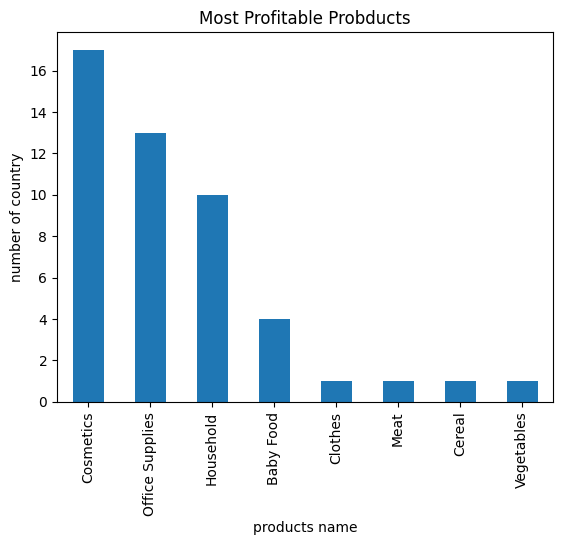

In [ ]:
pr['Proiftable Item'].value_counts().plot(kind='bar')
plt.title('Most Profitable Probducts')
plt.ylabel('number of country')
plt.xlabel('products name')

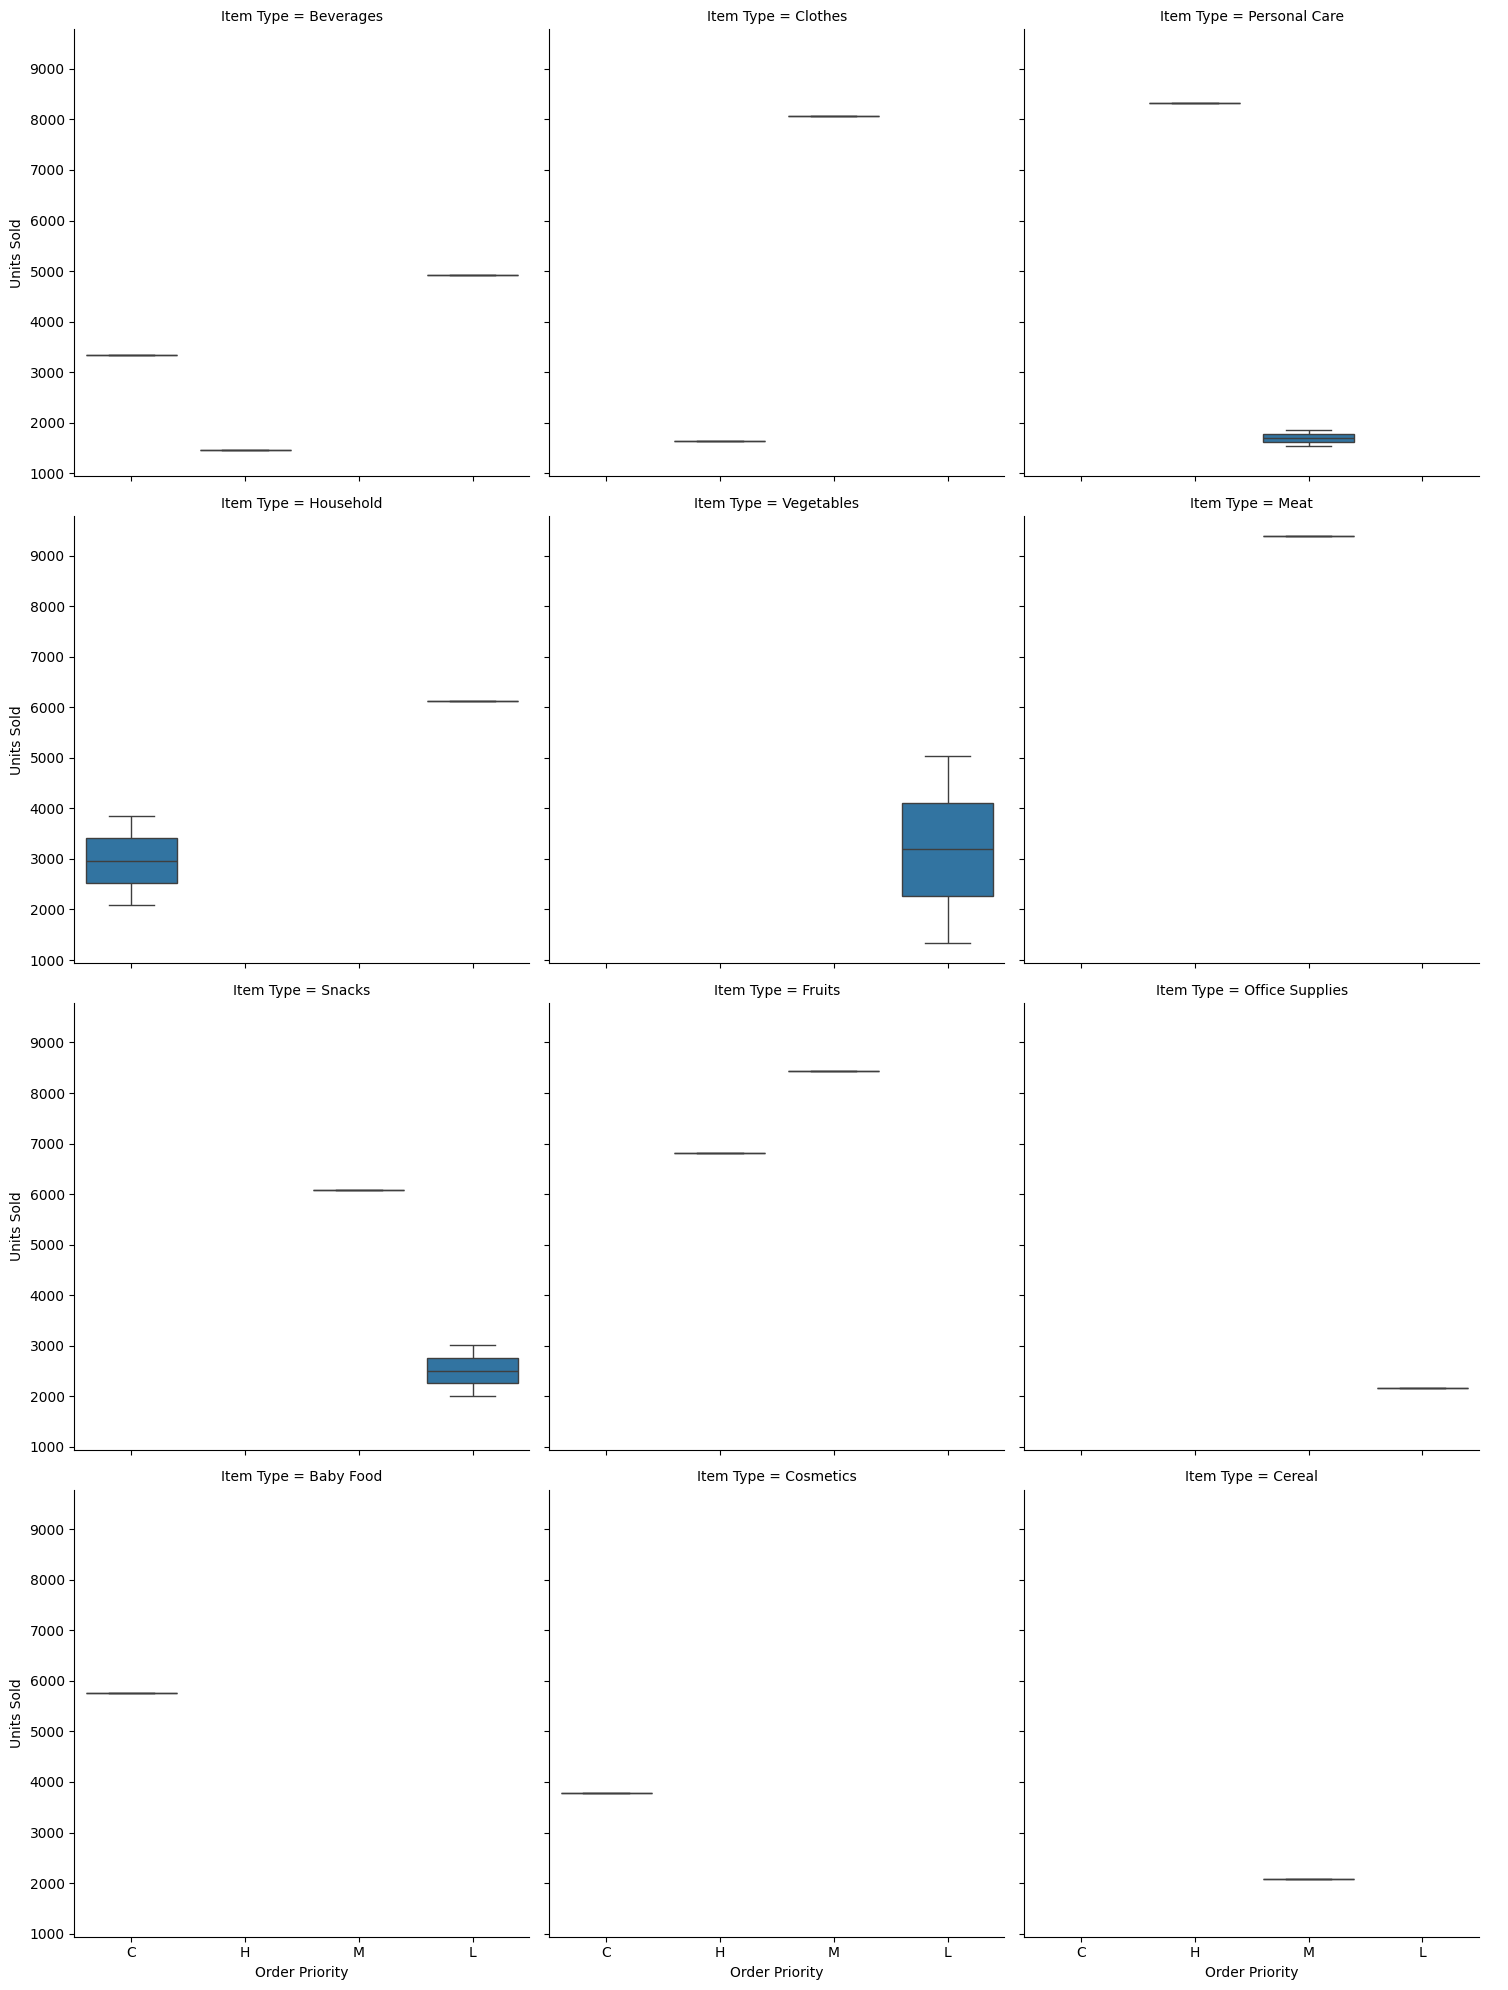

In [ ]:
#order priority --unit sold
sns.catplot(data=data,kind='box',x='Order Priority',y='Units Sold',col='Item Type',col_wrap=3)

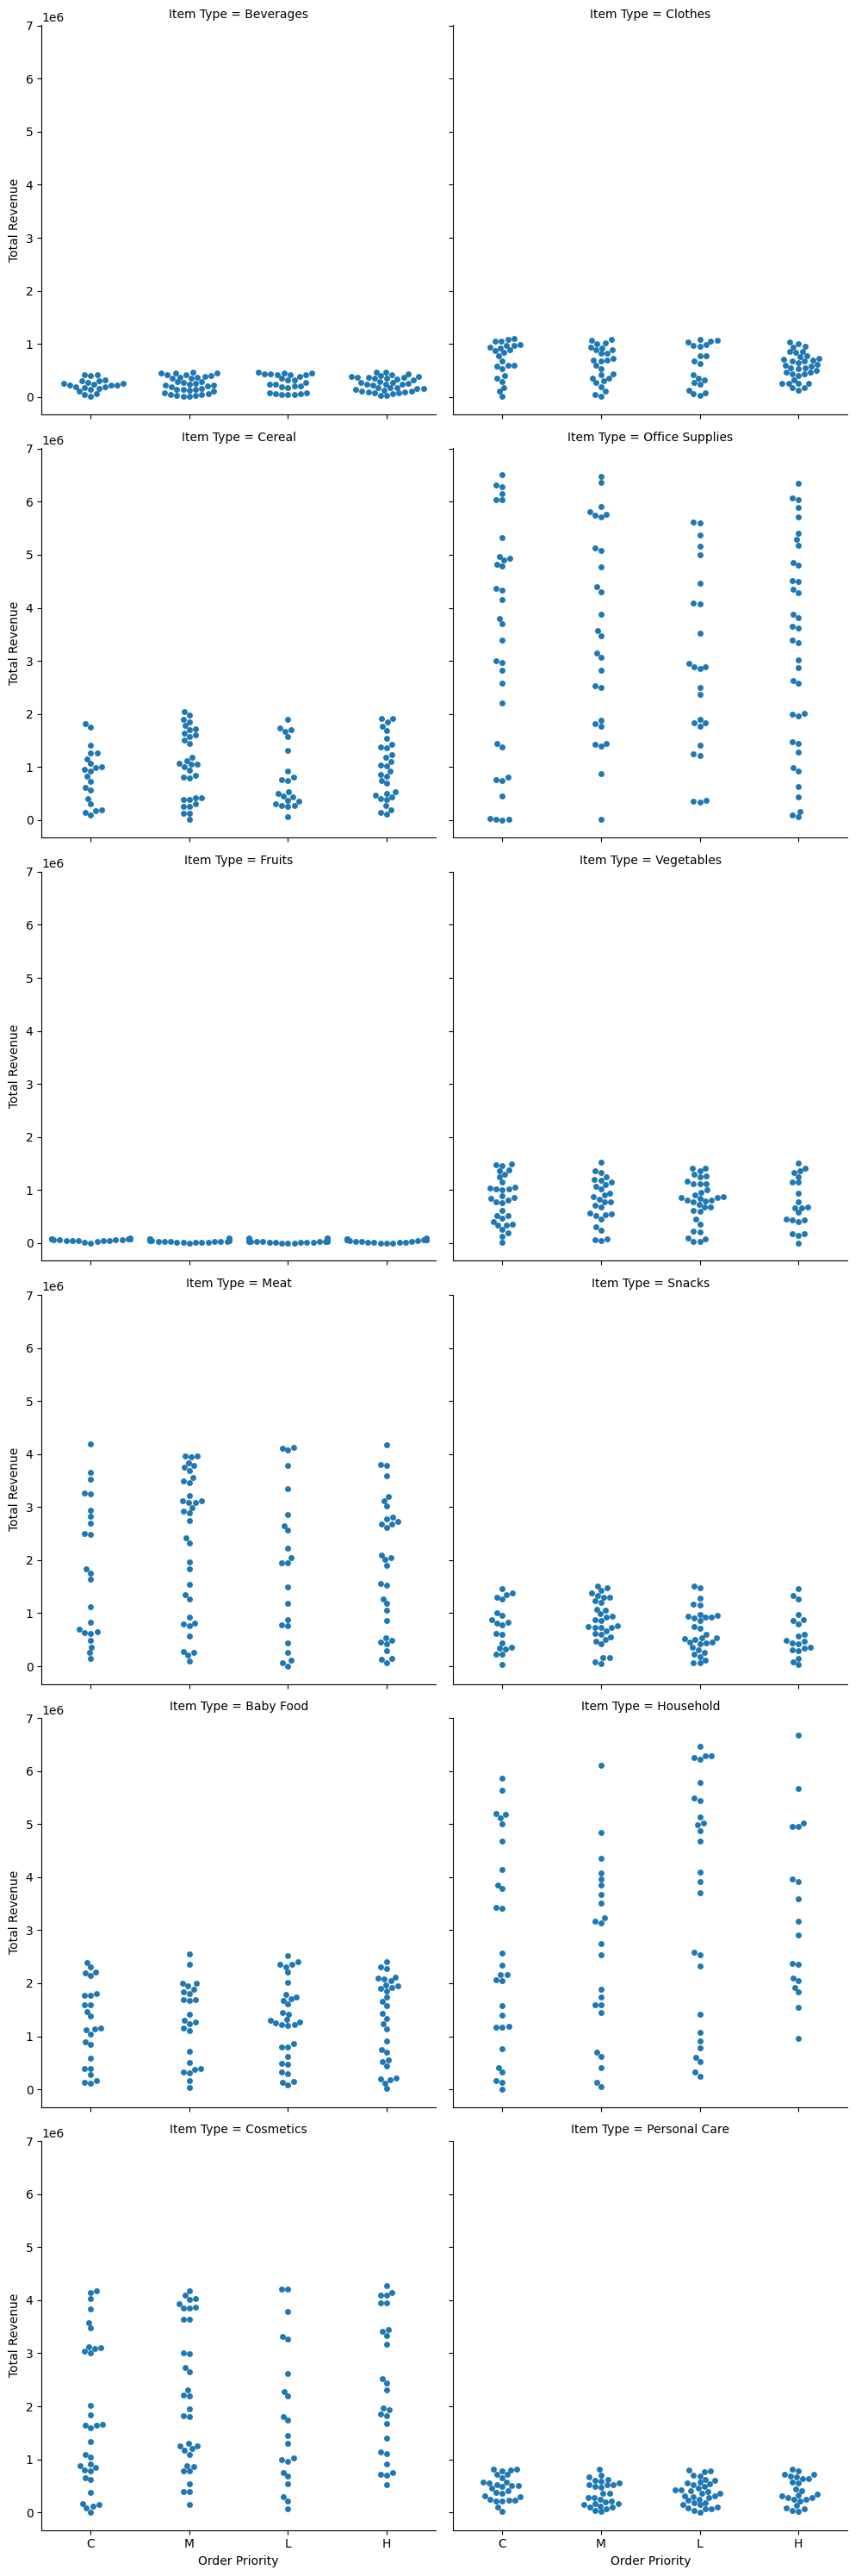

In [ ]:
#order priority --Revenue
sns.catplot(data=data,kind='swarm',x='Order Priority',y='Total Revenue',col='Item Type',col_wrap=2, n_boot= 10)

In [ ]:
#products wise shipment delay

shp_max_min=data.groupby('Item Type')['shipment_delay'].agg(['max','min'])
shp_max_min

,max,min
Item Type,,
Baby Food,46 days,46 days
Beverages,48 days,1 days
Cereal,35 days,35 days
Clothes,9 days,7 days
Cosmetics,12 days,12 days
Fruits,38 days,37 days
Household,43 days,16 days
Meat,24 days,24 days
Office Supplies,1 days,1 days
